<a href="https://colab.research.google.com/github/bettyblankson/Deep-Learning-Prosit_1/blob/main/DL_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
import seaborn as sns
import zipfile
import os

In [35]:
#!rm -rf /content/CCINIC-10   # remove if it already exists
!mkdir /content/CCINIC-10
!unzip -q "/content/drive/MyDrive/CINIC-10.zip" -d /content/CCINIC-10
!ls /content/CCINIC-10

imagenet-contributors.csv  synsets-to-cifar-10-classes.txt  train
README.md		   test				    valid


In [47]:
data_dir = '/content/CCINIC-10'

In [37]:
class SimpleCNN(nn.Module):
    def __init__(self, n_classes=10, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [38]:
def get_loaders(data_dir, batch_size=256, train_frac=1.0):
    # CINIC-10 mean & std
    cinic_mean = [0.47889522, 0.47227842, 0.43047404]
    cinic_std  = [0.24205776, 0.23828046, 0.25874835]

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(cinic_mean, cinic_std)  ##Normalizing the input
    ])

    train_ds = datasets.ImageFolder(os.path.join(data_dir,'train'), transform=transform)
    val_ds   = datasets.ImageFolder(os.path.join(data_dir,'valid'), transform=transform)
    test_ds  = datasets.ImageFolder(os.path.join(data_dir,'test'), transform=transform)

    # #Choose random 50% of training Data
    # if train_frac < 1.0:
    #     num_train = len(train_ds)
    #     np.random.seed(42)  # reproducibility to always pick random 50% and not any random
    #     indices = np.random.choice(num_train, int(num_train * train_frac), replace=False)
    #     train_ds = Subset(train_ds, indices)

    return (DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2),
            DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2),
            DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2))


In [39]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()*imgs.size(0)
        _, preds = outputs.max(1)
        correct += (preds==labels).sum().item()
        total += imgs.size(0)
    return running_loss/total, correct/total

In [40]:
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()*imgs.size(0)
            _, preds = outputs.max(1)
            correct += (preds==labels).sum().item()
            total += imgs.size(0)
    return running_loss/total, correct/total



In [50]:
def test_and_report(model, test_loader, device, class_names):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Accuracy
    acc = accuracy_score(all_labels, all_preds)
    print(f"Test Accuracy: {acc * 100:.2f}%")

    # Confusion matrix
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=False, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()




In [42]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


Epoch 1: train_loss=1.5698 train_acc=0.4177 val_loss=1.3779 val_acc=0.4936
Epoch 2: train_loss=1.3001 train_acc=0.5246 val_loss=1.1950 val_acc=0.5620
Epoch 3: train_loss=1.2002 train_acc=0.5649 val_loss=1.1054 val_acc=0.5974
Epoch 4: train_loss=1.1301 train_acc=0.5936 val_loss=1.1059 val_acc=0.5975
Epoch 5: train_loss=1.0796 train_acc=0.6128 val_loss=1.0995 val_acc=0.6068
Epoch 6: train_loss=1.0304 train_acc=0.6313 val_loss=1.0066 val_acc=0.6376
Epoch 7: train_loss=0.9944 train_acc=0.6446 val_loss=1.0818 val_acc=0.6214
Epoch 8: train_loss=0.9539 train_acc=0.6576 val_loss=0.9835 val_acc=0.6473
Epoch 9: train_loss=0.9176 train_acc=0.6691 val_loss=0.9899 val_acc=0.6491
Epoch 10: train_loss=0.8859 train_acc=0.6810 val_loss=0.9727 val_acc=0.6542
Epoch 11: train_loss=0.8574 train_acc=0.6907 val_loss=0.9792 val_acc=0.6544
Epoch 12: train_loss=0.8223 train_acc=0.7025 val_loss=1.0202 val_acc=0.6479
Epoch 13: train_loss=0.7984 train_acc=0.7094 val_loss=0.9535 val_acc=0.6621
Epoch 14: train_loss=

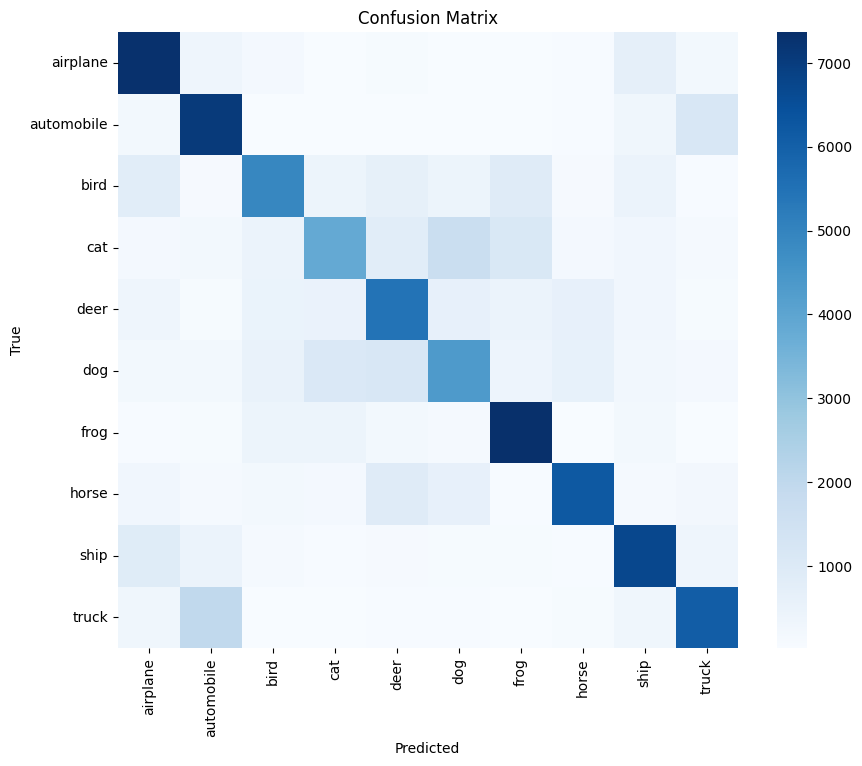

In [48]:
#device = 'cuda' if torch.cuda.is_available() else 'cpu'
train_loader, val_loader, test_loader = get_loaders(data_dir, batch_size=256)
class_names = train_loader.dataset.classes

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

best_val_acc = 0.0
epochs = 15

# Lists to store metrics
train_losses, val_losses = [], []
train_accs, val_accs = [], []



for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    print(f'Epoch {epoch+1}: train_loss={train_loss:.4f} train_acc={train_acc:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}')
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_dnn_cinic.pth')
model.load_state_dict(torch.load('best_dnn_cinic.pth', map_location=device))
test_and_report(model, test_loader, device, class_names)

Test Accuracy: 65.92%


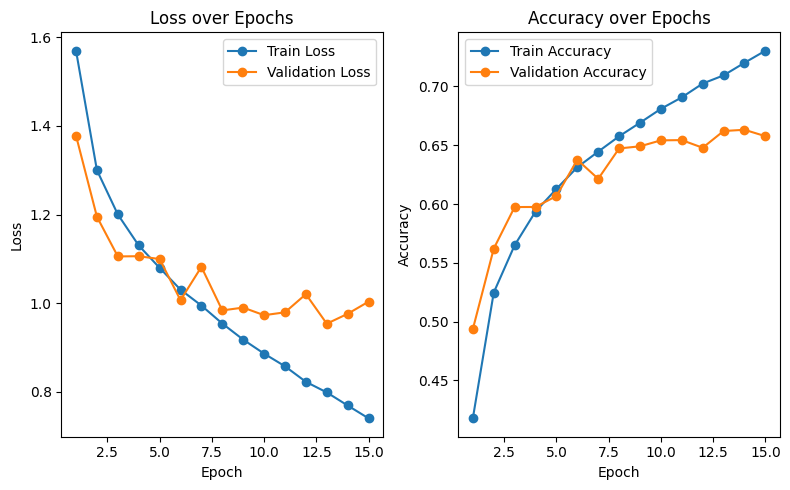

In [52]:
test_and_report(model, test_loader, device, class_names)
# Plot Loss
plt.figure(figsize=(8,5))
plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss',marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

# Plot Accuracy
plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), train_accs, label='Train Accuracy', marker='o')
plt.plot(range(1, epochs+1), val_accs, label='Validation Accuracy', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.tight_layout()
plt.show()